Prueba

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from keras.models import Sequential
from keras.layers import Dense, Dropout, GRU, InputLayer, Flatten, LSTM
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
import random


LEER DATASET

In [2]:
import pandas as pd

datos = pd.read_csv("C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\SNconsumptionFinal.csv")
datos['date'] = pd.to_datetime(datos['date'])

# Se establece la columna date como index
datos.set_index('date', inplace=True)


In [3]:
datos.head()

,temp,zone1,zone2,zone3,hour
date,,,,,
2017-01-01 00:00:00,6.559,34055.69620,16128.87538,20240.96386,0
2017-01-01 00:10:00,6.414,29814.68354,19375.07599,20131.08434,0
2017-01-01 00:20:00,6.313,29128.10127,19006.68693,19668.43373,0
2017-01-01 00:30:00,6.121,28228.86076,18361.09422,18899.27711,0
2017-01-01 00:40:00,5.921,27335.69620,17872.34043,18442.40964,0


In [4]:
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe input es un tipo de dato: ", datos.index.dtype)


El index del dataframe input es un tipo de dato:  datetime64[ns]


Se divide el dataset

In [5]:
# Dividir el conjunto de datos en entrenamiento y prueba
train, test = train_test_split(datos, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
test, val = train_test_split(test, test_size=0.33, shuffle=False)

print("Las dimensiones de train son: ", train.shape)
print("Las dimensiones de test son: ", test.shape)
print("Las dimensiones de val son: ", val.shape)



Las dimensiones de train son:  (36691, 5)
Las dimensiones de test son:  (10535, 5)
Las dimensiones de val son:  (5190, 5)


Se normalizan los datos

In [6]:
from sklearn.preprocessing import StandardScaler


# Normalizar solo con los datos de entrenamiento
scaler = StandardScaler()
train = scaler.fit_transform(train)

# Aplicar la transformación a test y val usando los parámetros de train
test = scaler.transform(test)
val = scaler.transform(val)

train = pd.DataFrame(train, columns=datos.columns)
test = pd.DataFrame(test, columns=datos.columns)
val = pd.DataFrame(val, columns=datos.columns)


Se unen los datos nuevamente, ahora normalizados, en un único conjunto.

In [7]:
datosNormalizados = pd.concat([train, test, val])

datosNormalizados.index = datos.index


In [8]:
datosNormalizados.shape

(52416, 5)

In [9]:
datosNormalizados.head(13)


,temp,zone1,zone2,zone3,hour
date,,,,,
2017-01-01 00:00:00,-2.051356,0.151445,-0.851669,0.033500,-1.660858
2017-01-01 00:10:00,-2.074813,-0.433079,-0.211097,0.016502,-1.660858
2017-01-01 00:20:00,-2.091152,-0.527709,-0.283791,-0.055068,-1.660858
2017-01-01 00:30:00,-2.122213,-0.651648,-0.411186,-0.174054,-1.660858
2017-01-01 00:40:00,-2.154568,-0.774750,-0.507632,-0.244729,-1.660858
2017-01-01 00:50:00,-2.165569,-0.872729,-0.597600,-0.293039,-1.660858
2017-01-01 01:00:00,-2.199865,-0.958984,-0.681090,-0.321667,-1.516340
2017-01-01 01:10:00,-2.223323,-1.035189,-0.746587,-0.396816,-1.516340
2017-01-01 01:20:00,-2.193880,-1.127306,-0.832236,-0.463913,-1.516340


Se establece el formato de datos de entrada para redes GRU y LSTM, es decir [observaciones, retardos, caracteristicas]

In [10]:
futuros = 1
pasados  = 12

In [11]:
datosX = []
datosY = []
for i in range(pasados, len(datosNormalizados) - futuros + 1):
  datosX.append(datosNormalizados.iloc[i-pasados:i, 0:datosNormalizados.shape[1]])
  datosY.append(datosNormalizados.iloc[i+futuros-1:i+futuros, 1])


In [12]:
# Convertir las listas en arrays numpy
datosX = np.array(datosX)
datosY = np.array(datosY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de X:", datosX.shape)  # (n_muestras, pasos_de_tiempo, n_características)
print("Dimensiones de Y:", datosY.shape)  # (n_muestras, n_características)

Dimensiones de X: (52404, 12, 5)
Dimensiones de Y: (52404, 1)


In [13]:
inputs = datosX.shape[1] * datosX.shape[2]
datosMLPX = datosX.reshape(datosX.shape[0], inputs)

In [14]:
print(datosX[0])
print(datosMLPX[0])

[[-2.05135573  0.15144479 -0.85166941  0.03349964 -1.66085756]
 [-2.07481311 -0.43307937 -0.21109699  0.01650173 -1.66085756]
 [-2.0911524  -0.52770864 -0.28379117 -0.05506842 -1.66085756]
 [-2.12221321 -0.65164785 -0.41118591 -0.17405378 -1.66085756]
 [-2.15456823 -0.77474965 -0.50763164 -0.2447293  -1.66085756]
 [-2.16556893 -0.87272862 -0.59759968 -0.29303915 -1.66085756]
 [-2.19986525 -0.95898362 -0.68109001 -0.32166721 -1.51634012]
 [-2.22332263 -1.03518949 -0.74658674 -0.39681586 -1.51634012]
 [-2.19387957 -1.12730648 -0.83223632 -0.46391287 -1.51634012]
 [-2.22413151 -1.19597551 -0.88909611 -0.49969795 -1.51634012]
 [-2.22008713 -1.24873342 -0.98842083 -0.52385287 -1.51634012]
 [-2.22736701 -1.29730419 -1.03232523 -0.5614272  -1.51634012]]
[-2.05135573  0.15144479 -0.85166941  0.03349964 -1.66085756 -2.07481311
 -0.43307937 -0.21109699  0.01650173 -1.66085756 -2.0911524  -0.52770864
 -0.28379117 -0.05506842 -1.66085756 -2.12221321 -0.65164785 -0.41118591
 -0.17405378 -1.66085756

Se dividen nuevamente los conjuntos de datos

In [15]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainX, testX = train_test_split(datosX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testX, valX = train_test_split(testX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainX son: ", trainX.shape)
print("Las dimensiones de testX son: ", testX.shape)
print("Las dimensiones de valX son: ", valX.shape)


Las dimensiones de trainX son:  (36682, 12, 5)
Las dimensiones de testX son:  (10533, 12, 5)
Las dimensiones de valX son:  (5189, 12, 5)


In [16]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainMLPX, testMLPX = train_test_split(datosMLPX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testMLPX, valMLPX = train_test_split(testMLPX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainMLPX son: ", trainMLPX.shape)
print("Las dimensiones de testMLPX son: ", testMLPX.shape)
print("Las dimensiones de valMLPX son: ", valMLPX.shape)

Las dimensiones de trainMLPX son:  (36682, 60)
Las dimensiones de testMLPX son:  (10533, 60)
Las dimensiones de valMLPX son:  (5189, 60)


In [17]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainY, testY = train_test_split(datosY, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testY, valY = train_test_split(testY, test_size=0.33, shuffle=False)

print("Las dimensiones de trainY son: ", trainY.shape)
print("Las dimensiones de testY son: ", testY.shape)
print("Las dimensiones de valY son: ", valY.shape)

Las dimensiones de trainY son:  (36682, 1)
Las dimensiones de testY son:  (10533, 1)
Las dimensiones de valY son:  (5189, 1)


Se crean métricas para medir desempeño

In [18]:
import tensorflow.keras.backend as K

def smape(y_true, y_pred):
    """
    Define la función SMAPE (Error Porcentual Absoluto Medio Simétrico).
    """
    summ = K.abs(y_true) + K.abs(y_pred)
    smape_val = K.abs(y_pred - y_true) / summ * 2.0
    return K.mean(smape_val, axis=-1)

def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

def ia(y_true, y_pred):
    numerator = K.sum(K.abs(y_true - y_pred))
    denominator = K.sum(K.abs(y_true - K.mean(y_true)) + K.abs(y_pred - K.mean(y_true)))
    return 1 - (numerator / denominator)

In [19]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae

def graficarPrediccion(modelo, x, y, inicio, final):
  predicciones = modelo.predict(x)
  predicciones = predicciones.flatten()
  df = pd.DataFrame({'Originales': y, 'Predichos': predicciones})
  plt.plot(df.index, df['Originales'][inicio:final], label='Originales')
  plt.plot(df.index, df['Predichos'][inicio:final], label='Predichos')
  return df, mse(y, predicciones),  mae(y, predicciones), rmse(y, predicciones), smape(y,predicciones), ia(y, predicciones)

Se define el index del conjunto de validación para utilizarlo posteriormente para graficar.

In [20]:
# Fecha y hora de término del conjunto de datos de prueba
end_date = datosNormalizados.index[-1]
n_observations = valY.shape[0]  

# Calcular la fecha y hora de inicio
start_date = end_date - timedelta(minutes=10 * (n_observations - 1))

# Crear la serie de fechas y horas
val_date = pd.date_range(start=start_date, end=end_date, freq='10T')

val_date

C:\Users\wamt1\AppData\Local\Temp\ipykernel_2192\2689359807.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  val_date = pd.date_range(start=start_date, end=end_date, freq='10T')


DatetimeIndex(['2017-11-24 23:10:00', '2017-11-24 23:20:00',
               '2017-11-24 23:30:00', '2017-11-24 23:40:00',
               '2017-11-24 23:50:00', '2017-11-25 00:00:00',
               '2017-11-25 00:10:00', '2017-11-25 00:20:00',
               '2017-11-25 00:30:00', '2017-11-25 00:40:00',
               ...
               '2017-12-30 22:20:00', '2017-12-30 22:30:00',
               '2017-12-30 22:40:00', '2017-12-30 22:50:00',
               '2017-12-30 23:00:00', '2017-12-30 23:10:00',
               '2017-12-30 23:20:00', '2017-12-30 23:30:00',
               '2017-12-30 23:40:00', '2017-12-30 23:50:00'],
              dtype='datetime64[ns]', length=5189, freq='10min')

Se guardan los índices de las observaciones a utilizar para predecir

In [21]:
indices = []
for i in range(pasados, len(datosNormalizados) - futuros + 1):
  indices.append(datosNormalizados.index[i+futuros-1])

# Modelos


## MLP

In [22]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [22]:
modelMLP = Sequential()
modelMLP.add(InputLayer(input_shape=(trainMLPX.shape[1],)))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(1))

opt = Adam(learning_rate=0.00027101707182655693)

modelMLP.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelMLP.summary()








c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,473 (224.50 KB)

 Trainable params: 57,473 (224.50 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)


early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyMLP = modelMLP.fit(trainMLPX, trainY, epochs=1, validation_data=(testMLPX, testY), verbose = 2, batch_size=16, callbacks=[early_stopping])

prediccionMLP = modelMLP.predict(valMLPX)


2293/2293 - 7s - 3ms/step - ia: 0.9534 - loss: 0.0127 - mae: 0.0728 - rmse: 0.0936 - smape: 0.2094 - val_ia: 0.8028 - val_loss: 0.0042 - val_mae: 0.0473 - val_rmse: 0.0593 - val_smape: 0.1358
Restoring model weights from the end of the best epoch: 1.
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [24]:
metricasMLP = modelMLP.evaluate(valMLPX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasMLP}")

163/163 - 0s - 1ms/step - ia: 0.8778 - loss: 0.0034 - mae: 0.0466 - rmse: 0.0570 - smape: 0.1363
Métricas en el conjunto de validación: [0.003442737739533186, 0.046631425619125366, 0.13627852499485016, 0.05704646185040474, 0.8777915239334106]


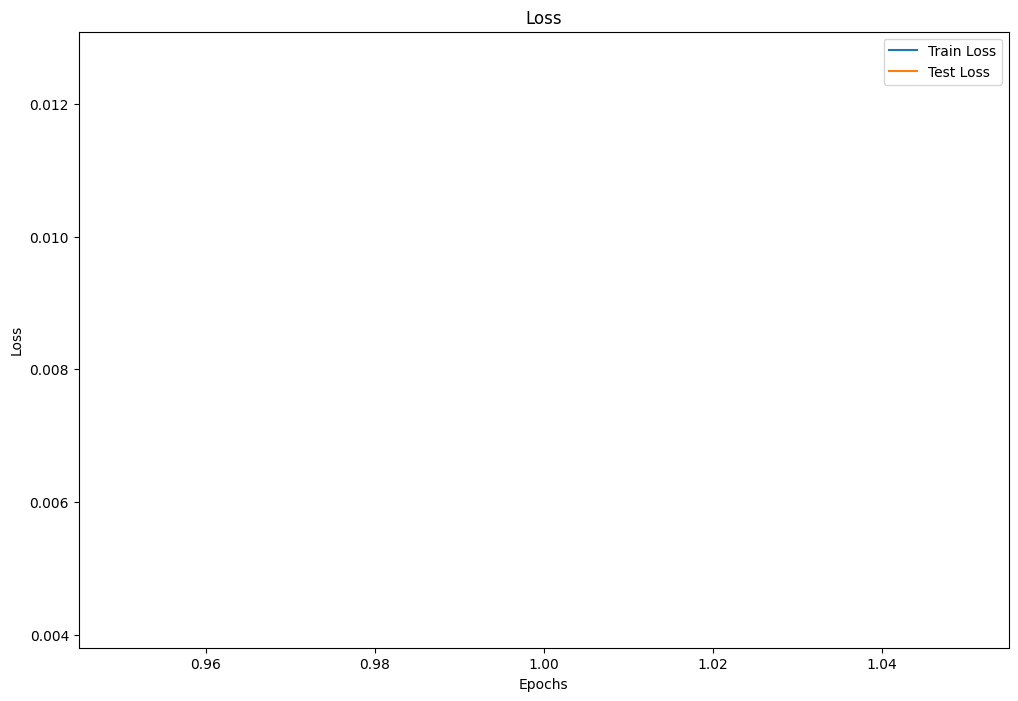

In [25]:
historyMLP = historyMLP.history
ejeXMLP = range(1, len(historyMLP['loss']) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXMLP, historyMLP['loss'], label='Train Loss')
plt.plot(ejeXMLP, historyMLP['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [26]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyMLP['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyMLP['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.012662521563470364
Último valor de Test Loss: 0.00423061940819025


In [27]:
print(len(prediccionMLP))

5189


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionMLP.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]

fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')

fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfMLP = df
fig.show()

In [40]:
dfMLP

,Originales,Predichos
2017-11-24 23:10:00,-0.308303,-0.215899
2017-11-24 23:20:00,-0.403297,-0.309491
2017-11-24 23:30:00,-0.525433,-0.403307
2017-11-24 23:40:00,-0.616186,-0.543376
2017-11-24 23:50:00,-0.689976,-0.648855
...,...,...
2017-12-30 23:10:00,-0.247596,-0.108642
2017-12-30 23:20:00,-0.348215,-0.260018
2017-12-30 23:30:00,-0.463926,-0.381931
2017-12-30 23:40:00,-0.551129,-0.511496


In [41]:
valY

array([[-0.30830272],
       [-0.40329702],
       [-0.52543255],
       ...,
       [-0.46392619],
       [-0.551129  ],
       [-0.63497785]])

### Datos para NARMAX

In [34]:
prediccionNarmaxMLP = modelMLP.predict(datosMLPX)
erroresMLP = datosY - prediccionNarmaxMLP 

1638/1638 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [35]:
dfErroresMLP = pd.DataFrame(erroresMLP, columns = ["e"])
dfErroresMLP.index = indices

In [36]:
dfErroresMLP

,e
2017-01-01 02:00:00,-0.007657
2017-01-01 02:10:00,-0.094768
2017-01-01 02:20:00,-0.036857
2017-01-01 02:30:00,-0.021774
2017-01-01 02:40:00,-0.049731
...,...
2017-12-30 23:10:00,-0.138954
2017-12-30 23:20:00,-0.088196
2017-12-30 23:30:00,-0.081995
2017-12-30 23:40:00,-0.039634


In [38]:
dfNarmaxMLP = datosNormalizados.join(dfErroresMLP, how = 'left')
dfNarmaxMLP.head(13)

,temp,zone1,zone2,zone3,hour,e
date,,,,,,
2017-01-01 00:00:00,-2.051356,0.151445,-0.851669,0.033500,-1.660858,NaN
2017-01-01 00:10:00,-2.074813,-0.433079,-0.211097,0.016502,-1.660858,NaN
2017-01-01 00:20:00,-2.091152,-0.527709,-0.283791,-0.055068,-1.660858,NaN
2017-01-01 00:30:00,-2.122213,-0.651648,-0.411186,-0.174054,-1.660858,NaN
2017-01-01 00:40:00,-2.154568,-0.774750,-0.507632,-0.244729,-1.660858,NaN
2017-01-01 00:50:00,-2.165569,-0.872729,-0.597600,-0.293039,-1.660858,NaN
2017-01-01 01:00:00,-2.199865,-0.958984,-0.681090,-0.321667,-1.516340,NaN
2017-01-01 01:10:00,-2.223323,-1.035189,-0.746587,-0.396816,-1.516340,NaN
2017-01-01 01:20:00,-2.193880,-1.127306,-0.832236,-0.463913,-1.516340,NaN


In [32]:
dfNarmaxMLP.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\1pasos_mlp_consumption.csv', index=True)



In [ ]:
dfMLP.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\evaluacion\\1pasos_mlp_consumption.csv', index=True)

## LSTM

In [33]:
modelLSTM = Sequential()
modelLSTM.add(InputLayer(input_shape=(trainX.shape[1], trainX.shape[2])))

modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=True))
modelLSTM.add(Dropout(0.0))


modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=True))
modelLSTM.add(Dropout(0.0))


modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=True))
modelLSTM.add(Dropout(0.0))

modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=False))
modelLSTM.add(Dropout(0.0))

modelLSTM.add(Dense(1))


opt = Adam(learning_rate=0.00027101707182655693)
modelLSTM.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelLSTM.summary()



c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning:

Argument `input_shape` is deprecated. Use `shape` instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 463,489 (1.77 MB)

 Trainable params: 463,489 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)


early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyLSTM = modelLSTM.fit(trainX, trainY, epochs=128, validation_data=(testX, testY), verbose = 2, batch_size=16, callbacks=[early_stopping])


prediccionLSTM = modelLSTM.predict(valX)

Epoch 1/128
2293/2293 - 98s - 43ms/step - ia: 0.9130 - loss: 0.0451 - mae: 0.1320 - rmse: 0.1739 - smape: 0.3284 - val_ia: 0.7681 - val_loss: 0.0069 - val_mae: 0.0629 - val_rmse: 0.0763 - val_smape: 0.1959
Epoch 2/128
2293/2293 - 83s - 36ms/step - ia: 0.9702 - loss: 0.0046 - mae: 0.0466 - rmse: 0.0618 - smape: 0.1544 - val_ia: 0.8412 - val_loss: 0.0030 - val_mae: 0.0385 - val_rmse: 0.0492 - val_smape: 0.1173
Epoch 3/128
2293/2293 - 72s - 32ms/step - ia: 0.9730 - loss: 0.0038 - mae: 0.0422 - rmse: 0.0563 - smape: 0.1420 - val_ia: 0.8391 - val_loss: 0.0030 - val_mae: 0.0384 - val_rmse: 0.0490 - val_smape: 0.1140
Epoch 4/128
2293/2293 - 74s - 32ms/step - ia: 0.9739 - loss: 0.0037 - mae: 0.0408 - rmse: 0.0547 - smape: 0.1386 - val_ia: 0.8432 - val_loss: 0.0029 - val_mae: 0.0377 - val_rmse: 0.0483 - val_smape: 0.1156
Epoch 5/128
2293/2293 - 68s - 30ms/step - ia: 0.9746 - loss: 0.0035 - mae: 0.0397 - rmse: 0.0534 - smape: 0.1353 - val_ia: 0.8484 - val_loss: 0.0027 - val_mae: 0.0366 - val_rms

In [35]:
metricasLSTM = modelLSTM.evaluate(valX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasLSTM}")

163/163 - 2s - 11ms/step - ia: 0.9226 - loss: 0.0019 - mae: 0.0334 - rmse: 0.0428 - smape: 0.1139
Métricas en el conjunto de validación: [0.0019453612621873617, 0.03340352326631546, 0.11393987387418747, 0.0427529513835907, 0.9226471781730652]


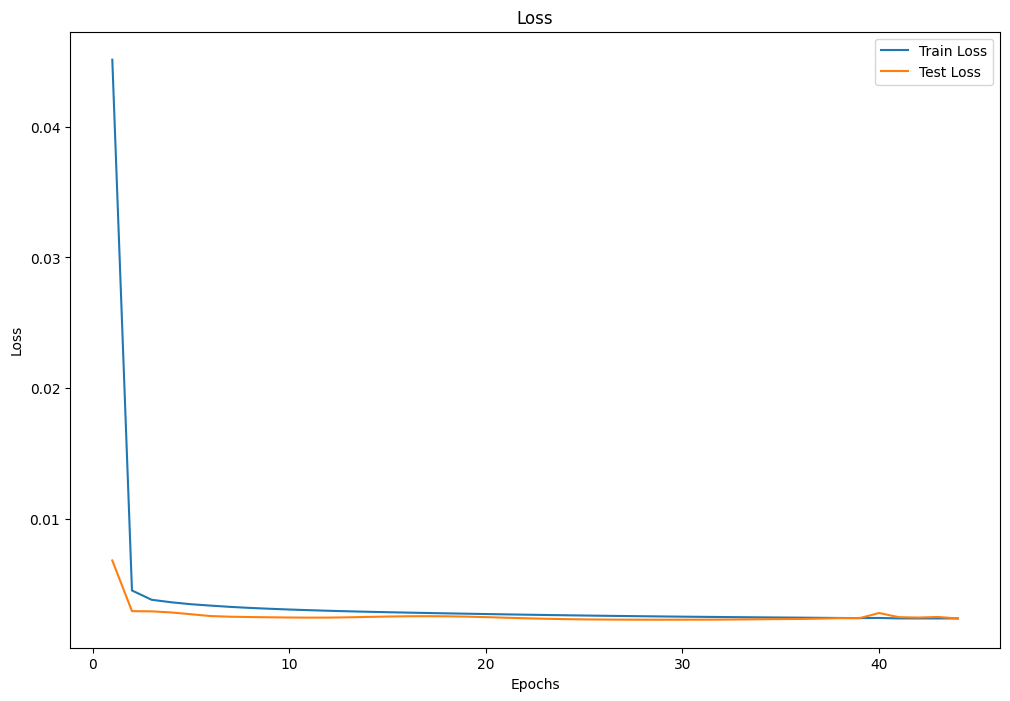

In [36]:
historyLSTM = historyLSTM.history

ejeXLSTM = range(1, len(historyLSTM['loss']) + 1)

plt.figure(figsize=(12, 8))
plt.plot(ejeXLSTM, historyLSTM['loss'], label='Train Loss')
plt.plot(ejeXLSTM, historyLSTM['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [37]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyLSTM['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyLSTM['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.002423237543553114
Último valor de Test Loss: 0.0024166046641767025


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionLSTM.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))

fig.show()


### Datos para NARMAX

In [39]:
prediccionNarmaxLSTM = modelLSTM.predict(datosX)
erroresLSTM = datosY - prediccionNarmaxLSTM 

1638/1638 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step


In [40]:
dfErroresLSTM = pd.DataFrame(erroresLSTM, columns = ["e"])
dfErroresLSTM.index = indices

In [41]:
dfNarmaxLSTM = datosNormalizados.join(dfErroresLSTM, how = 'left')

print(dfNarmaxLSTM.head())
print(dfNarmaxLSTM.tail())

                         temp     zone1     zone2     zone3      hour   e
date                                                                     
2017-01-01 00:00:00 -2.051356  0.151445 -0.851669  0.033500 -1.660858 NaN
2017-01-01 00:10:00 -2.074813 -0.433079 -0.211097  0.016502 -1.660858 NaN
2017-01-01 00:20:00 -2.091152 -0.527709 -0.283791 -0.055068 -1.660858 NaN
2017-01-01 00:30:00 -2.122213 -0.651648 -0.411186 -0.174054 -1.660858 NaN
2017-01-01 00:40:00 -2.154568 -0.774750 -0.507632 -0.244729 -1.660858 NaN
                         temp     zone1     zone2     zone3      hour  \
date                                                                    
2017-12-30 23:10:00 -1.978395 -0.247596  1.265373 -0.811241  1.663044   
2017-12-30 23:20:00 -1.988587 -0.348215  1.120782 -0.865616  1.663044   
2017-12-30 23:30:00 -1.996190 -0.463926  0.953666 -0.961888  1.663044   
2017-12-30 23:40:00 -2.019162 -0.551129  0.838138 -1.007350  1.663044   
2017-12-30 23:50:00 -2.047958 -0.634978  0.7

In [42]:
dfNarmaxLSTM.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\1pasos_lstm_consumption.csv', index=True)

## GRU

In [43]:
modelGRU = Sequential()
modelGRU.add(InputLayer(input_shape=(trainX.shape[1], trainX.shape[2])))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=True))
modelGRU.add(Dropout(0.0))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=True))
modelGRU.add(Dropout(0.0))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=True))
modelGRU.add(Dropout(0.0))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=False))
modelGRU.add(Dropout(0.0))

modelGRU.add(Dense(1))


opt = Adam(learning_rate=0.00027101707182655693)
modelGRU.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelGRU.summary()




c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning:

Argument `input_shape` is deprecated. Use `shape` instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 128)        │        51,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 12, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 12, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 349,185 (1.33 MB)

 Trainable params: 349,185 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)

early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyGRU = modelGRU.fit(trainX, trainY, epochs=8, validation_data=(testX, testY), verbose = 2, batch_size=16, callbacks=[early_stopping])

prediccionGRU = modelGRU.predict(valX)

Epoch 1/8


In [45]:
metricasGRU = modelGRU.evaluate(valX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasGRU}")

163/163 - 2s - 10ms/step - ia: 0.9253 - loss: 0.0017 - mae: 0.0298 - rmse: 0.0392 - smape: 0.0990
Métricas en el conjunto de validación: [0.0016660583205521107, 0.02984626404941082, 0.09904999285936356, 0.0391724519431591, 0.9252752661705017]


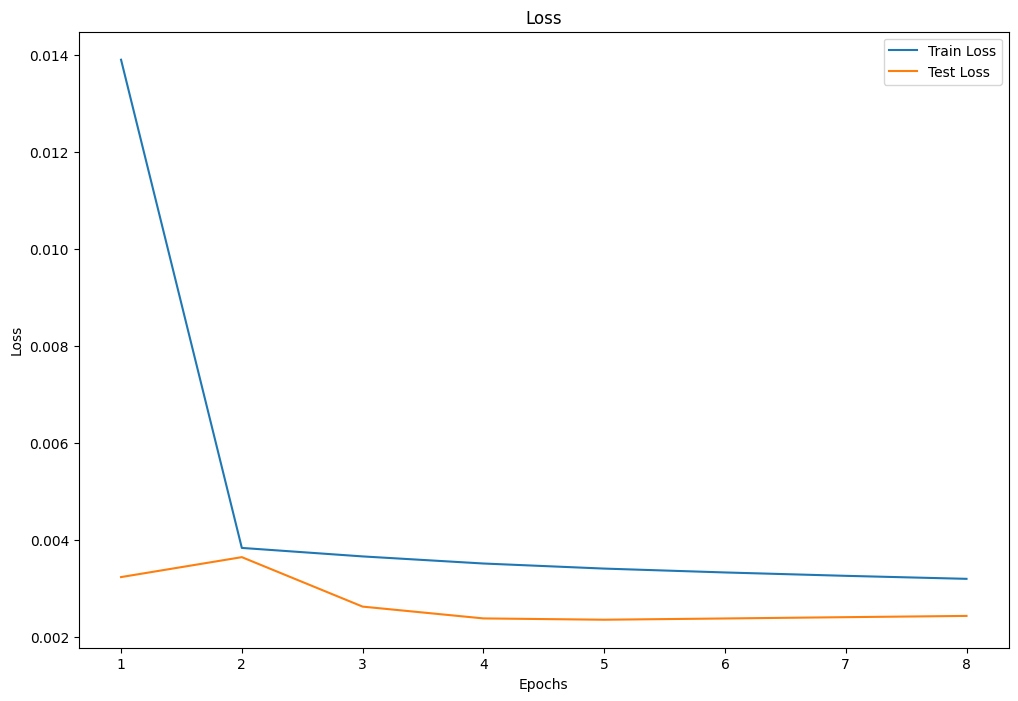

In [46]:
historyGRU = historyGRU.history

ejeXGRU = range(1, len(historyGRU['loss']) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXGRU, historyGRU['loss'], label='Train Loss')
plt.plot(ejeXGRU, historyGRU['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [47]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyGRU['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyGRU['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.0032020562794059515
Último valor de Test Loss: 0.0024373510386794806


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionGRU.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))

fig.show()

### Datos para NARMAX

In [49]:
prediccionNarmaxGRU = modelGRU.predict(datosX)
erroresGRU = datosY - prediccionNarmaxGRU

1638/1638 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step


In [50]:
dfErroresGRU = pd.DataFrame(erroresGRU, columns = ["e"])
dfErroresGRU.index = indices

In [51]:
dfNarmaxGRU = datosNormalizados.join(dfErroresGRU, how = 'left')

print(dfNarmaxGRU.head())
print(dfNarmaxGRU.tail())

                         temp     zone1     zone2     zone3      hour   e
date                                                                     
2017-01-01 00:00:00 -2.051356  0.151445 -0.851669  0.033500 -1.660858 NaN
2017-01-01 00:10:00 -2.074813 -0.433079 -0.211097  0.016502 -1.660858 NaN
2017-01-01 00:20:00 -2.091152 -0.527709 -0.283791 -0.055068 -1.660858 NaN
2017-01-01 00:30:00 -2.122213 -0.651648 -0.411186 -0.174054 -1.660858 NaN
2017-01-01 00:40:00 -2.154568 -0.774750 -0.507632 -0.244729 -1.660858 NaN
                         temp     zone1     zone2     zone3      hour  \
date                                                                    
2017-12-30 23:10:00 -1.978395 -0.247596  1.265373 -0.811241  1.663044   
2017-12-30 23:20:00 -1.988587 -0.348215  1.120782 -0.865616  1.663044   
2017-12-30 23:30:00 -1.996190 -0.463926  0.953666 -0.961888  1.663044   
2017-12-30 23:40:00 -2.019162 -0.551129  0.838138 -1.007350  1.663044   
2017-12-30 23:50:00 -2.047958 -0.634978  0.7

In [52]:
dfNarmaxGRU.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\1pasos_gru_consumption.csv', index=True)